In [1]:

import os

# Pick physical GPU 2 before importing torch in this kernel session.
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

from glp.denoiser import load_glp
from glp import flow_matching, script_eval, script_steer
from glp.utils_acts import save_acts
from gemma2_pipeline.loading import iter_fineweb_texts, load_model_and_tokenizer
from gemma2_pipeline.preprocess import batch_items
from gemma2_pipeline.settings import FineWebSourceConfig

/mnt/disk1/aiotlab/envs/glp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

import torch

print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("Visible logical GPUs:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("Logical cuda:0:", torch.cuda.get_device_name(0))

CUDA_VISIBLE_DEVICES: 1
Visible logical GPUs: 1
Logical cuda:0: NVIDIA A30


**Load the GLP**

You can just put the HuggingFace repo and the checkpoint will be automatically downloaded for you.

In [3]:
# With CUDA_VISIBLE_DEVICES=2, physical GPU 2 is remapped to logical cuda:0.
device = "cuda:0"

# Your Gemma GLP checkpoint (local folder or HF repo id).
glp_name = "PQPQPQHUST/glp-gpt2-med"
glp_ckpt = "1B/ot_gauss/300M"

# Gemma LLM setup for streaming reference activations and steering.
hf_model_name = "openai-community/gpt2-medium"
hf_layer = 12
vector_path = "Vector/CAA/extracted/GPT2/med/vector.pt"

In [4]:
import time

t0 = time.time()
try:
    model, mean, var = load_glp(glp_name, device=device, checkpoint=glp_ckpt, local_files_only=True)
    print("Loaded GLP from local cache.")
except Exception as cache_err:
    print(f"Local cache miss ({type(cache_err).__name__}), falling back to online download.")
    model, mean, var = load_glp(glp_name, device=device, checkpoint=glp_ckpt, local_files_only=False)
model = model.to(torch.bfloat16)
model.eval()
embedding_dim = model.denoiser.model.d_input
print(f"GLP loaded in {time.time() - t0:.1f}s | embedding_dim={embedding_dim}")
print(f"Normalizer method: {getattr(model.normalizer, 'normalization_method', 'gaussian')}")

Local cache miss (FileNotFoundError), falling back to online download.


Fetching 3 files: 100%|██████████| 3/3 [00:18<00:00,  6.07s/it]


GLP loaded in 20.2s | embedding_dim=1024
Normalizer method: gaussian


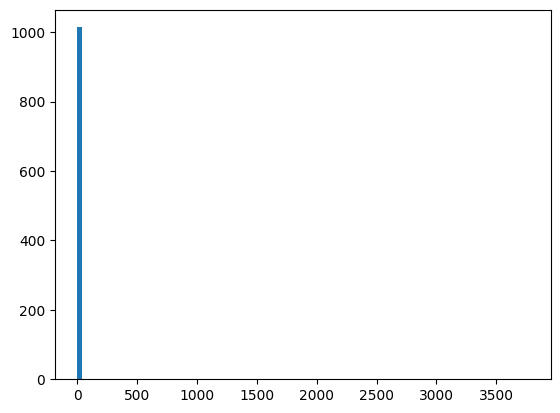

In [5]:
plt.hist(var.cpu().numpy(), bins=100)
plt.show()

**Checking GLP Quality**

Now that we've loaded up the model, we can sanity check that it's working by generating some activations.

In [6]:
def generate_activations(num_timesteps, batch_size, generator=None):
    print("Generating activations...")
    noise = torch.randn(batch_size, 1, embedding_dim, generator=generator).to(device)
    gen_latents = flow_matching.sample(model, noise, num_timesteps=num_timesteps)
    # map normalized latents back to activation space (gaussian or log_norm inverse)
    gen_latents = model.normalizer.denormalize(gen_latents)
    return gen_latents


def stream_reference_activations(
    hf_model,
    hf_tokenizer,
    layer,
    num_vectors=20000,
    dataset_name="HuggingFaceFW/fineweb",
    dataset_config="sample-10BT",
    split="train",
    text_field="text",
    max_documents=None,
    document_batch_size=16,
    forward_batch_size=1,
    max_length=1024,
    drop_bos=True,
):
    tracedict_config = {
        "layer_prefix": "transformer.h",
        "layers": [layer],
        "retain": "output",
    }
    fineweb_cfg = FineWebSourceConfig(
        dataset_name=dataset_name,
        dataset_config=dataset_config,
        split=split,
        text_field=text_field,
        streaming=True,
        max_documents=max_documents,
    )

    text_iter = iter_fineweb_texts(fineweb_cfg)
    chunks = []
    vectors_written = 0
    for text_batch in tqdm(
        batch_items(text_iter, document_batch_size),
        desc="Streaming FineWeb acts",
        dynamic_ncols=True,
    ):
        acts = save_acts(
            hf_model=hf_model,
            hf_tokenizer=hf_tokenizer,
            text=text_batch,
            tracedict_config=tracedict_config,
            padding_side="right",
            token_idx="all",
            batch_size=forward_batch_size,
            max_length=max_length,
        )
        vecs = acts[:, 0, :, :]
        if drop_bos and vecs.shape[1] > 1:
            vecs = vecs[:, 1:, :]
        vecs = vecs.reshape(-1, vecs.shape[-1])
        if vecs.shape[0] == 0:
            continue

        remaining = num_vectors - vectors_written
        vecs = vecs[:remaining]
        chunks.append(vecs.cpu())
        vectors_written += vecs.shape[0]
        if vectors_written >= num_vectors:
            break

    if vectors_written == 0:
        raise RuntimeError("No reference activations were collected from FineWeb streaming.")

    ref_latents = torch.cat(chunks, dim=0)[:, None, :]
    print(f"Collected {ref_latents.shape[0]} streamed reference vectors.")
    return ref_latents



def compute_fd(ref_latents, gen_latents, generator=None):
    ref_vecs = ref_latents[:, 0, :].detach().cpu().float()
    gen_vecs = gen_latents[:, 0, :].detach().cpu().float()
    
    n = min(ref_vecs.shape[0], gen_vecs.shape[0])
    if n < 2:
        raise ValueError("Need at least 2 vectors per set to compute Frechet Distance.")
    
    # Compute FD(generated, reference)
    fd_gen_ref = script_eval.rep_fd(ref_vecs[:n].float().numpy(), gen_vecs[:n].float().numpy())
    
    # Generate noise samples from standard normal distribution
    if generator is None:
        generator = torch.Generator()
    noise_vecs = torch.randn(n, ref_vecs.shape[1], generator=generator).float()
    
    # Compute FD(noise, reference)
    fd_noise_ref = script_eval.rep_fd(ref_vecs[:n].float().numpy(), noise_vecs[:n].float().numpy())
    
    # Return normalized FD
    # Avoid division by zero
    if fd_noise_ref < 1e-8:
        return float('inf')
    return fd_gen_ref / fd_noise_ref

    
def plot_pca(num_timesteps, batch_size, ref_latents, gen_latents):
    gen_latents = gen_latents[:, 0, :].detach().cpu()
    ref_latents = ref_latents[:, 0, :].detach().cpu()
    gen_latents = gen_latents[:batch_size, :]
    ref_latents = ref_latents[:batch_size, :]
    title = f"Num Timesteps: {num_timesteps}"
    print("Plotting PCA...")
    return script_eval.plot_pca(
        ref_latents,
        gen_latents,
        label_X="Real",
        label_Y="Generated",
        title=title,
        alpha=0.8,
        half_mask=num_timesteps >= 10,
    )

In [7]:
from pathlib import Path

ref_num_vectors = 50000
ref_cache = Path(f"data/frechet-stream-{hf_model_name.split('/')[-1]}-layer{hf_layer}-{ref_num_vectors}.pt")

if ref_cache.exists():
    print(f"Loading cached streamed reference activations from {ref_cache}")
    ref_latents = torch.load(ref_cache)["activations"]
else:
    print("Loading Gemma model for streaming references...")
    hf_model, hf_tokenizer = load_model_and_tokenizer(
        model_name=hf_model_name,
        device=device,
        torch_dtype_name="bfloat16",
    )
    ref_latents = stream_reference_activations(
        hf_model=hf_model,
        hf_tokenizer=hf_tokenizer,
        layer=hf_layer,
        num_vectors=ref_num_vectors,
        dataset_name="HuggingFaceFW/fineweb",
        dataset_config="sample-10BT",
        split="train",
        text_field="text",
        document_batch_size=16,
        forward_batch_size=1,
        max_length=1024,
    ).float()
    ref_cache.parent.mkdir(parents=True, exist_ok=True)
    torch.save({"activations": ref_latents}, ref_cache)
    print(f"Saved streamed references to {ref_cache}")

Loading cached streamed reference activations from data/frechet-stream-gpt2-medium-layer12-50000.pt


Below, you will see PCA plots and Frechet Distance scores against streamed FineWeb references.

- Low Frechet Distance means generated activations are closer to the real reference distribution.
- High Frechet Distance means generated activations are farther from the reference distribution.

If streaming is slow, reduce ref_num_vectors or max_length in the previous cell.

In [8]:
# Keep these evaluation hyperparameters aligned with glp_demo.ipynb
batch_size = 50000
eval_timesteps = [1, 20]
fd_eval_vectors = min(batch_size, ref_latents.shape[0])

Generating activations...


1it [00:00,  1.19it/s]


Plotting PCA...
Generating activations...


20it [00:07,  2.81it/s]


Plotting PCA...


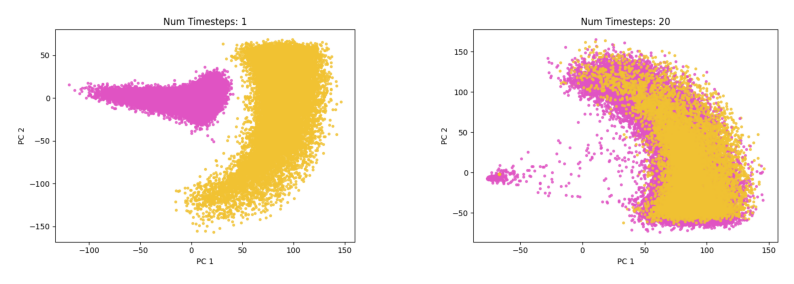

,frechet_distance
num_timesteps,
1,0.96
20,0.05


In [9]:
# run generation
generator = torch.Generator().manual_seed(12)
pca_plots = []
fd_rows = []
generated_latents_by_step = {}

for num_timesteps in eval_timesteps:
    gen_latents = generate_activations(num_timesteps, batch_size, generator=generator)
    generated_latents_by_step[num_timesteps] = gen_latents.detach().cpu()
    pca_plot = plot_pca(num_timesteps, batch_size, ref_latents, gen_latents)
    pca_plots.append(pca_plot)
    fd_rows.append({
        "num_timesteps": num_timesteps,
        "frechet_distance": compute_fd(ref_latents[:fd_eval_vectors], gen_latents[:fd_eval_vectors], generator=generator),
    })

# visualize the PCA results
plt.figure(figsize=(5 * len(pca_plots), 5))
for i in range(len(pca_plots)):
    plt.subplot(1, len(pca_plots), i + 1)
    plt.imshow(pca_plots[i])
    plt.axis("off")
plt.show()

# show Frechet Distance summary
fd_df = pd.DataFrame(fd_rows).set_index("num_timesteps").sort_index()
fd_df.round(2)

**Distribution Evaluation: Fair Quality vs Raw-Dimension Attribution**

Frechet Distance is useful as a historical baseline, but it mixes scale, mean, covariance, and heavy-tail effects. For Gemma activations we use three separate diagnostics instead:

1. **Fair global quality:** robust Median/IQR scaling on raw activations, then global MMD with an IMQ kernel. This asks whether generated and reference distributions match after high-variance dimensions are put on a fair scale.
2. **Fair global sliced geometry:** robust Median/IQR scaling on raw activations, then sliced Wasserstein over random 1D projections. This asks whether joint cross-dimensional geometry matches under the same fair scale.
3. **Surgical attribution:** raw unnormalized activations, then independent 1D Wasserstein distance for each hidden dimension. This asks which dimensions are actually broken in raw activation space.

Keep the original full-covariance FD table above as a continuity baseline; use the metrics below for debugging and model selection.



In [10]:
def _activation_vectors(latents):
    """Return [n, d] activation vectors on CPU float32 from [n, 1, d] or [n, d]."""
    vecs = latents.detach().cpu().float()
    if vecs.ndim == 3:
        vecs = vecs[:, 0, :]
    if vecs.ndim != 2:
        raise ValueError(f"Expected [n, d] or [n, 1, d], got {tuple(vecs.shape)}")
    return vecs


def _align_samples(ref_latents, gen_latents, max_vectors=None):
    ref = _activation_vectors(ref_latents)
    gen = _activation_vectors(gen_latents)
    n = min(ref.shape[0], gen.shape[0])
    if max_vectors is not None:
        n = min(n, int(max_vectors))
    if n < 2:
        raise ValueError("Need at least 2 vectors per set.")
    return ref[:n].contiguous(), gen[:n].contiguous()


def fit_robust_iqr_scaler(ref_vecs, eps=1e-6):
    """Fit Median/IQR scaler on reference raw activations only."""
    median = ref_vecs.median(dim=0).values
    q25 = torch.quantile(ref_vecs, 0.25, dim=0)
    q75 = torch.quantile(ref_vecs, 0.75, dim=0)
    iqr = (q75 - q25).clamp_min(eps)
    return median, iqr


def apply_robust_iqr_scaler(vecs, median, iqr, clip=None):
    scaled = (vecs - median) / iqr
    clip_rate = (vecs.abs() > clip).float().mean().item()
    print(f"Warning: {clip_rate * 100:.2f}% of data was clipped.")
    if clip is not None:
        scaled = scaled.clamp(min=-float(clip), max=float(clip))
    return scaled


def _imq_kernel_sum(x, y, constants, chunk_size=512, exclude_diag=False):
    """Sum IMQ kernel values over all pairs without materializing the full matrix."""
    total = x.new_tensor(0.0)
    count = 0
    constants = torch.as_tensor(constants, device=x.device, dtype=x.dtype)

    for i in range(0, x.shape[0], chunk_size):
        xb = x[i:i + chunk_size]
        for j in range(0, y.shape[0], chunk_size):
            yb = y[j:j + chunk_size]
            dist2 = torch.cdist(xb, yb, p=2).pow(2)
            k = constants[:, None, None] / (constants[:, None, None] + dist2[None, :, :])
            k = k.mean(dim=0)
            if exclude_diag and x.data_ptr() == y.data_ptr() and i == j:
                diag_n = min(k.shape[0], k.shape[1])
                diag_idx = torch.arange(diag_n, device=k.device)
                k = k.clone()
                k[diag_idx, diag_idx] = 0.0
                count += k.numel() - diag_n
            else:
                count += k.numel()
            total = total + k.sum()
    return total, count


def imq_mmd2(x, y, constants=None, chunk_size=512, unbiased=True):
    """Global MMD^2 with an IMQ kernel. Lower is better; 0 means identical distributions."""
    if x.shape[1] != y.shape[1]:
        raise ValueError(f"Dim mismatch: {x.shape[1]} vs {y.shape[1]}")
    d = x.shape[1]
    if constants is None:
        constants = [0.1 * d, 0.2 * d, 0.5 * d, 1.0 * d, 2.0 * d, 5.0 * d, 10.0 * d]

    xx_sum, xx_count = _imq_kernel_sum(x, x, constants, chunk_size=chunk_size, exclude_diag=unbiased)
    yy_sum, yy_count = _imq_kernel_sum(y, y, constants, chunk_size=chunk_size, exclude_diag=unbiased)
    xy_sum, xy_count = _imq_kernel_sum(x, y, constants, chunk_size=chunk_size, exclude_diag=False)

    mmd2 = xx_sum / xx_count + yy_sum / yy_count - 2.0 * xy_sum / xy_count
    return mmd2.clamp_min(0.0)


def fair_imq_mmd(ref_latents, gen_latents, max_vectors=2048, iqr_clip=20.0, chunk_size=512):
    """Fair global quality score: raw activations -> reference IQR scale -> IMQ MMD."""
    ref_raw, gen_raw = _align_samples(ref_latents, gen_latents, max_vectors=max_vectors)
    median, iqr = fit_robust_iqr_scaler(ref_raw)
    ref_scaled = apply_robust_iqr_scaler(ref_raw, median, iqr, clip=iqr_clip)
    gen_scaled = apply_robust_iqr_scaler(gen_raw, median, iqr, clip=iqr_clip)
    mmd2 = imq_mmd2(ref_scaled, gen_scaled, chunk_size=chunk_size, unbiased=True)
    return {
        "mmd2_imq_iqr": float(mmd2.item()),
        "mmd_imq_iqr": float(torch.sqrt(mmd2).item()),
        "num_vectors": int(ref_scaled.shape[0]),
        "iqr_clip": iqr_clip,
    }


def sliced_wasserstein_distance(ref_vecs, gen_vecs, num_projections=2000, seed=0):
    """Global sliced W1 over random 1D projections. Lower is better."""
    if ref_vecs.ndim != 2 or gen_vecs.ndim != 2:
        raise ValueError("Expected [num_vectors, dim] tensors.")
    if ref_vecs.shape != gen_vecs.shape:
        raise ValueError(f"Shape mismatch: {tuple(ref_vecs.shape)} vs {tuple(gen_vecs.shape)}")

    with torch.no_grad():
        ref = ref_vecs.float()
        gen = gen_vecs.float()
        _, dim = ref.shape

        generator = torch.Generator(device=ref.device)
        generator.manual_seed(int(seed))
        directions = torch.randn(
            dim,
            int(num_projections),
            device=ref.device,
            dtype=ref.dtype,
            generator=generator,
        )
        directions = directions / directions.norm(dim=0, keepdim=True).clamp_min(torch.finfo(ref.dtype).eps)

        proj_ref = ref @ directions
        proj_gen = gen @ directions
        ref_sorted = proj_ref.sort(dim=0).values
        gen_sorted = proj_gen.sort(dim=0).values
        return (ref_sorted - gen_sorted).abs().mean()


def fair_sliced_wasserstein(ref_latents, gen_latents, max_vectors=2048, iqr_clip=20.0, num_projections=2000, seed=0):
    """Fair global quality score: raw activations -> reference IQR scale -> sliced W1."""
    ref_raw, gen_raw = _align_samples(ref_latents, gen_latents, max_vectors=max_vectors)
    median, iqr = fit_robust_iqr_scaler(ref_raw)
    ref_scaled = apply_robust_iqr_scaler(ref_raw, median, iqr, clip=iqr_clip)
    gen_scaled = apply_robust_iqr_scaler(gen_raw, median, iqr, clip=iqr_clip)
    swd = sliced_wasserstein_distance(
        ref_scaled,
        gen_scaled,
        num_projections=num_projections,
        seed=seed,
    )
    return {
        "swd_iqr": float(swd.item()),
        "num_vectors": int(ref_scaled.shape[0]),
        "iqr_clip": iqr_clip,
        "num_projections": int(num_projections),
        "projection_seed": int(seed),
    }


def wasserstein_1d_per_dim(ref_latents, gen_latents, max_vectors=None):
    """Raw attribution score: exact 1D W1 for each dim using equal sample counts."""
    ref_raw, gen_raw = _align_samples(ref_latents, gen_latents, max_vectors=max_vectors)
    ref_sorted = ref_raw.sort(dim=0).values
    gen_sorted = gen_raw.sort(dim=0).values
    w1 = (ref_sorted - gen_sorted).abs().mean(dim=0)

    ref_mean = ref_raw.mean(dim=0)
    gen_mean = gen_raw.mean(dim=0)
    ref_var = ref_raw.var(dim=0, unbiased=False)
    gen_var = gen_raw.var(dim=0, unbiased=False)
    glp_var = var.detach().cpu().float().reshape(-1)

    df = pd.DataFrame({
        "dim": np.arange(ref_raw.shape[1]),
        "wasserstein_1d_raw": w1.numpy(),
        "ref_mean_raw": ref_mean.numpy(),
        "gen_mean_raw": gen_mean.numpy(),
        "mean_abs_error_raw": (gen_mean - ref_mean).abs().numpy(),
        "ref_var_raw": ref_var.numpy(),
        "gen_var_raw": gen_var.numpy(),
        "var_abs_error_raw": (gen_var - ref_var).abs().numpy(),
        "glp_var": glp_var.numpy(),
    })
    df["glp_var_rank"] = df["glp_var"].rank(method="min", ascending=False).astype(int)
    df["wasserstein_rank"] = df["wasserstein_1d_raw"].rank(method="min", ascending=False).astype(int)
    return df.sort_values("wasserstein_1d_raw", ascending=False).reset_index(drop=True)


def plot_raw_wasserstein_attribution(wass_df, top_k=20):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(wass_df["glp_var"], wass_df["wasserstein_1d_raw"], s=10, alpha=0.35)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("GLP raw variance")
    ax.set_ylabel("Raw 1D Wasserstein distance")
    ax.set_title("Raw per-dimension attribution")
    for _, row in wass_df.head(top_k).iterrows():
        ax.annotate(int(row["dim"]), (row["glp_var"], row["wasserstein_1d_raw"]), fontsize=8)
    plt.tight_layout()
    plt.show()



Evaluation timestep: 20
Fair global quality: Robust IQR -> IMQ MMD


,mmd2_imq_iqr,mmd_imq_iqr,num_vectors,iqr_clip
0,0.015467,0.124366,2048,30.0



Fair global quality: Robust IQR -> sliced Wasserstein


,swd_iqr,num_vectors,iqr_clip,num_projections,projection_seed
0,0.280883,2048,30.0,2000,0



Raw attribution: top 20 dimensions by 1D Wasserstein
Top-20 W1 dims that are also top-50 GLP variance dims: 18/20


,dim,wasserstein_1d_raw,wasserstein_rank,glp_var_rank,glp_var,ref_var_raw,gen_var_raw,mean_abs_error_raw,var_abs_error_raw
0,268,7.9048,1,1,3768.200684,3703.028809,3685.778076,7.3806,17.250700
1,580,7.7091,2,2,1559.587891,1298.084351,2019.504150,3.8326,721.419922
2,218,4.0668,3,4,336.194702,298.286407,340.865204,4.0033,42.578800
3,238,3.2431,4,3,1182.559570,1145.491211,1037.694580,1.5255,107.796600
4,590,2.5955,5,8,84.064301,78.616501,99.857697,2.5659,21.241100
5,121,2.0563,6,6,150.244705,138.945297,153.359207,2.0347,14.413900
6,608,1.9056,7,5,215.787201,222.117203,209.597595,1.5018,12.519500
7,689,1.4270,8,11,33.810902,32.152100,35.131901,1.4090,2.979800
8,803,1.4199,9,10,39.862301,36.804199,47.306599,1.4146,10.502400
9,373,1.1239,10,7,115.576599,123.746002,107.830101,0.4514,15.915900


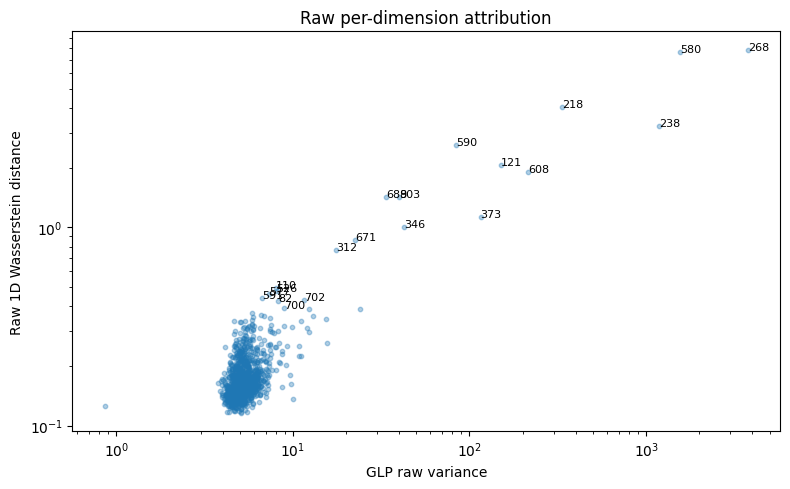

In [11]:
# Choose which generated distribution to evaluate.
eval_quality_timesteps = max(eval_timesteps)
eval_ref = ref_latents[:fd_eval_vectors]
eval_gen = generated_latents_by_step[eval_quality_timesteps][:fd_eval_vectors]

# MMD is O(n^2). Keep global metrics moderate; increase if you need lower-variance estimates.
global_metric_max_vectors = min(2048, fd_eval_vectors)
swd_num_projections = 2000
swd_seed = 0
wasserstein_max_vectors = fd_eval_vectors

fair_scores = fair_imq_mmd(
    eval_ref,
    eval_gen,
    max_vectors=global_metric_max_vectors,
    iqr_clip=30.0,
    chunk_size=512,
)

swd_scores = fair_sliced_wasserstein(
    eval_ref,
    eval_gen,
    max_vectors=global_metric_max_vectors,
    iqr_clip=30.0,
    num_projections=swd_num_projections,
    seed=swd_seed,
)

wass_df = wasserstein_1d_per_dim(
    eval_ref,
    eval_gen,
    max_vectors=wasserstein_max_vectors,
)

top_k = 20
top_wass = wass_df.head(top_k)
top_glp_dims = set(wass_df.sort_values("glp_var", ascending=False).head(50)["dim"])
top_wass_in_top_glp50 = top_wass["dim"].isin(top_glp_dims).sum()

print(f"Evaluation timestep: {eval_quality_timesteps}")
print("Fair global quality: Robust IQR -> IMQ MMD")
display(pd.DataFrame([fair_scores]))
print()
print("Fair global quality: Robust IQR -> sliced Wasserstein")
display(pd.DataFrame([swd_scores]))
print()
print(f"Raw attribution: top {top_k} dimensions by 1D Wasserstein")
print(f"Top-{top_k} W1 dims that are also top-50 GLP variance dims: {top_wass_in_top_glp50}/{top_k}")
display(top_wass[[
    "dim", "wasserstein_1d_raw", "wasserstein_rank", "glp_var_rank",
    "glp_var", "ref_var_raw", "gen_var_raw", "mean_abs_error_raw", "var_abs_error_raw",
]].round(4))

plot_raw_wasserstein_attribution(wass_df, top_k=top_k)



**On-Manifold Steering with GLP (Gemma-2-2B-it)**

Here we use a pre-computed Gemma steering vector and compare:
- normal generation
- steer only
- steer + GLP post-processing

In [12]:
# If streaming references already loaded Gemma, reuse it.
if "hf_model" not in globals() or "hf_tokenizer" not in globals():
    hf_model, hf_tokenizer = load_model_and_tokenizer(
        model_name=hf_model_name,
        device=device,
        torch_dtype_name="bfloat16",
    )
else:
    hf_model.to(torch.bfloat16)
    hf_model.eval()
    print("Reusing existing Gemma model/tokenizer from earlier cells.")

if hf_tokenizer.pad_token is None and hf_tokenizer.eos_token is not None:
    hf_tokenizer.pad_token = hf_tokenizer.eos_token
if getattr(hf_model.config, "pad_token_id", None) is None and hf_tokenizer.pad_token_id is not None:
    hf_model.config.pad_token_id = hf_tokenizer.pad_token_id
if getattr(hf_model, "generation_config", None) is not None and hf_model.generation_config.pad_token_id is None:
    hf_model.generation_config.pad_token_id = hf_tokenizer.pad_token_id

import importlib
script_steer = importlib.reload(script_steer)

In [13]:
question = "The boy heard the question and said: "

seed = 42
max_new_tokens = 80
temperature = 0.5
alphas = torch.tensor([0, 1, 2, 3, 5, 7, 10], dtype=torch.bfloat16)

glp_u = 0.3
glp_num_timesteps = 20

In [14]:
layer_name = f"transformer.h.{hf_layer}"

# Load one layer steering vector from a tensor or dict payload.
payload = torch.load(vector_path, map_location="cpu")
steer_vector = payload[hf_layer] if isinstance(payload, dict) else payload

if steer_vector is None:
    raise ValueError(f"Layer {hf_layer} not found in {vector_path}")
if steer_vector.ndim > 1:
    steer_vector = steer_vector.squeeze()
if steer_vector.ndim != 1:
    raise ValueError(f"Expected a 1D steering vector, got shape {tuple(steer_vector.shape)}")
steer_vector = steer_vector.to(device=hf_model.device, dtype=hf_model.dtype)
try:
    chat_prompt = hf_tokenizer.apply_chat_template(
        [{"role": "user", "content": question}],
        tokenize=False,
        add_generation_prompt=True,
    )
except:
    chat_prompt = question

settings = {
    "No Intervention": (None, None),
    "Steer Only": (script_steer.addition_intervention, None),
    "Steer + GLP": (
        script_steer.addition_intervention,
        script_steer.postprocess_on_manifold_wrapper(
            model,
            u=glp_u,
            num_timesteps=glp_num_timesteps,
            layer_idx=hf_layer,
        ),
    ),
}

results = {}
for setting, (intervention_wrapper, postprocess_fn) in settings.items():
    print(f"Running {setting}...")
    generate_with_intervention = script_steer.generate_with_intervention_wrapper(seed=seed)
    generate_kwargs = {
        "max_new_tokens": max_new_tokens,
        "do_sample": temperature > 0,
        "temperature": temperature,
        "pad_token_id": hf_tokenizer.eos_token_id,
    }

    if intervention_wrapper is None:
        gen_text = generate_with_intervention(
            [chat_prompt] * len(alphas),
            hf_model,
            hf_tokenizer,
            layers=[layer_name],
            intervention_wrapper=None,
            generate_kwargs=generate_kwargs,
        )
    else:
        gen_text = generate_with_intervention(
            [chat_prompt] * len(alphas),
            hf_model,
            hf_tokenizer,
            layers=[layer_name],
            intervention_wrapper=intervention_wrapper,
            intervention_kwargs={
                "w": steer_vector,
                "alphas": alphas.to(device=hf_model.device, dtype=hf_model.dtype),
                "postprocess_fn": postprocess_fn,
            },
            generate_kwargs=generate_kwargs,
        )
    results[setting] = gen_text

Running No Intervention...


Running Steer Only...
Running Steer + GLP...


In [15]:
# show results
pd.set_option('display.max_colwidth', None)
results_df = pd.DataFrame(results)
results_df.index = alphas.tolist()
results_df.columns = settings.keys()
results_df

,No Intervention,Steer Only,Steer + GLP
0.0,"""I don't know what you are talking about."" When I asked him what he was talking about, he replied: ""I don't know what you are talking about.""\nWhen I asked him what he was talking about, he replied: ""I don't know what you are talking about.""\nWhen I asked him what he was talking about, he replied: ""","""I don't know what you are talking about."" When I asked him what he was talking about, he replied: ""I don't know what you are talking about.""\nWhen I asked him what he was talking about, he replied: ""I don't know what you are talking about.""\nWhen I asked him what he was talking about, he replied: ""","""What is your favourite colour?""\nlocated on her face.\n The boy said:\n ""I don't like it.""\n The boy said: ""Why? Why?""\n\n The boy said: ""I don't like it.""\n effect of the colour ""I don't like it?""\n and the boy said: ""I don't like it.""\n's face""."
1.0,"""I don't know, but I don't want to.""\nThe boy was taken to the hospital, where he was treated for a broken nose and lacerations to his face.\nThe boy's parents, who are also from the city, told the newspaper that they did not want to press charges because the boy was too young to understand what he was doing.\nThe boy is","""I don't know, I'm not sure if I should answer or not."" \n""That's OK, I'll answer it."" \nThe boy then asked again, ""I don't know, I don't know, I don't know, I don't know, I don't know, I don't know, I don't know, I don't know, I","'I don't know, but I'm not ashamed.'\n the man said: 'I'm not ashamed of my boy.'\n the boy said: 'It's a boy.'\n the boy said: 'I'm not ashamed of my boy.'\n which one is it?\n the boy said: 'I'm not ashamed of my boy.'\n the boy"
2.0,"""I'm not going to go to the toilet."" When asked why he didn't go to the toilet, the boy replied: ""I don't want to go to the toilet."" The boy then stated that he had been drinking and was crying. The girl then said: ""He's not going to go to the toilet."" The boy then said: ""I'm not going to go to","""I'm not going to go to school today."" The man said, ""You're not going to school today."" The boy said, ""No I'm not."" The man said, ""I'm not going to go to school today."" The boy said, ""I'm not going to go to school today."" The man said, ""I'm not going to","""Your father's death is not your fault. You were in the middle of an argument with your father, and he had a problem with you. You fought with him for years, and he tried to kill you.""\n your father's death is not your fault. You were in the middle of an argument with your father, and he had a problem with you"
3.0,"""I am a boy."" The boy said: ""Yes, I am a boy."" The boy said: ""I am a boy."" The boy said: ""I am a boy."" The boy said: ""I am a boy."" The boy said: ""I am a boy."" The boy said: ""I am a boy","""I don't know.""\n""Who told you to tell me?""\nThe boy said: ""I don't know.""\n""I don't know.""\n""I don't know.""\n""I don't know.""\n""I don't know.""\n""I don't know.""\n""I don't know.""\n""I don't know.""\n""","""What do you want to be?"" The boy looked at the boy, and then smiled: ""I don't know, I'm not sure."" The boy said: ""I don't know either."" The boy smiled: ""I don't know either either."" The boy smiled. The boy said: ""I don't know either."" The boy smiled."
5.0,"""Yes, I did.""\nThe boy was then asked if he had seen the boy before. The boy replied that he had not and that the boy was in a car with a man who was ""not a good guy."" The man then said that the boy had been shot in the back and that the boy had been shot in the head. The boy then","?""I don't know, I don't know. I don't know.""\n\n""Well, I don't know either, I'm not interested,"" the man replied.\n\n""I don't know either,"" the boy replied.\n\n""Do you understand?""\n\n""I don't know either,"" the boy replied.\n\n""Well, I don't understand either,""","I'm not sure. I."". ""I's. I's. I's. I's."". . I's."". . I's."". . I's."". ."". I's."". I's.""."". I's."". I's.""."". I's

**Perplexity Sweep for Steering**

This section sweeps steering coefficient, GLP post-process timesteps, and `glp_u` noise rate, then scores the generated continuation text with perplexity under the base GPT-2-medium model.

The baseline is the no-intervention generation for the same prompt and seed. The table below reports mean perplexity, mean change vs baseline, and the best configuration by the smallest perplexity increase or largest reduction. If every setting is worse than baseline, the notebook will call out the least harmful configuration.

In [16]:
def score_continuation_perplexity(texts, tokenizer, lm_model, batch_size=8):
    """Return per-text perplexity for decoded continuations."""
    lm_model.eval()
    rows = []
    device = next(lm_model.parameters()).device
    pad_token_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else -100

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]
        enc = tokenizer(batch_texts, return_tensors="pt", padding=True, truncation=False).to(device)

        with torch.no_grad():
            logits = lm_model(**enc).logits.float()

        if logits.shape[1] < 2:
            for text in batch_texts:
                rows.append({
                    "text": text,
                    "num_tokens": 0,
                    "mean_nll": float("nan"),
                    "perplexity": float("nan"),
                })
            continue

        shift_logits = logits[:, :-1, :]
        shift_labels = enc["input_ids"][:, 1:].clone()
        shift_mask = enc["attention_mask"][:, 1:].float()
        shift_labels = shift_labels.masked_fill(shift_mask == 0, -100)

        token_nll = torch.nn.functional.cross_entropy(
            shift_logits.reshape(-1, shift_logits.shape[-1]),
            shift_labels.reshape(-1),
            reduction="none",
            ignore_index=-100,
        ).view_as(shift_labels)

        token_mask = shift_labels.ne(-100).float()
        token_counts = token_mask.sum(dim=1)
        mean_nll = torch.full_like(token_counts, float("nan"), dtype=torch.float32)
        valid = token_counts > 0
        if valid.any():
            mean_nll[valid] = (token_nll * token_mask)[valid].sum(dim=1) / token_counts[valid]

        ppl = torch.exp(mean_nll)
        for text, count, nll_value, ppl_value in zip(batch_texts, token_counts, mean_nll, ppl):
            rows.append({
                "text": text,
                "num_tokens": int(count.item()),
                "mean_nll": float(nll_value.item()) if torch.isfinite(nll_value) else float("nan"),
                "perplexity": float(ppl_value.item()) if torch.isfinite(ppl_value) else float("nan"),
            })

    return pd.DataFrame(rows)


def generate_texts_for_setting(prompt_text, alpha_values, postprocess_fn, seed, max_new_tokens, temperature):
    generate_with_intervention = script_steer.generate_with_intervention_wrapper(seed=seed)
    generate_kwargs = {
        "max_new_tokens": max_new_tokens,
        "do_sample": temperature > 0,
        "temperature": temperature,
        "pad_token_id": hf_tokenizer.eos_token_id,
    }
    if postprocess_fn is None:
        return generate_with_intervention(
            [prompt_text] * len(alpha_values),
            hf_model,
            hf_tokenizer,
            layers=[layer_name],
            intervention_wrapper=script_steer.addition_intervention,
            intervention_kwargs={
                "w": steer_vector,
                "alphas": torch.tensor(alpha_values, device=hf_model.device, dtype=hf_model.dtype),
                "postprocess_fn": lambda x: x,
            },
            generate_kwargs=generate_kwargs,
        )

    return generate_with_intervention(
        [prompt_text] * len(alpha_values),
        hf_model,
        hf_tokenizer,
        layers=[layer_name],
        intervention_wrapper=script_steer.addition_intervention,
        intervention_kwargs={
            "w": steer_vector,
            "alphas": torch.tensor(alpha_values, device=hf_model.device, dtype=hf_model.dtype),
            "postprocess_fn": postprocess_fn,
        },
        generate_kwargs=generate_kwargs,
    )


def summarize_perplexity_sweep(sweep_rows):
    sweep_df = pd.DataFrame(sweep_rows)
    if sweep_df.empty:
        raise RuntimeError("No sweep rows were produced.")

    summary_df = (
        sweep_df
        .groupby(["glp_u", "glp_num_timesteps"], as_index=False)
        .agg(
            baseline_ppl=("baseline_ppl", "first"),
            mean_steer_only_ppl=("steer_only_ppl", "mean"),
            mean_denoised_ppl=("denoised_ppl", "mean"),
            mean_glp_reduction=("ppl_reduction_after_glp", "mean"),
            median_glp_reduction=("ppl_reduction_after_glp", "median"),
            best_glp_reduction=("ppl_reduction_after_glp", "max"),
            best_steer_coeff=("steer_coeff", lambda s: float(s.loc[sweep_df.loc[s.index, "ppl_reduction_after_glp"].idxmax()])),
        )
    )
    summary_df["mean_steer_only_delta_vs_baseline"] = summary_df["mean_steer_only_ppl"] - summary_df["baseline_ppl"]
    summary_df["mean_denoised_delta_vs_baseline"] = summary_df["mean_denoised_ppl"] - summary_df["baseline_ppl"]
    summary_df["mean_glp_reduction_pct"] = 100.0 * summary_df["mean_glp_reduction"] / summary_df["baseline_ppl"]
    summary_df["best_glp_reduction_pct"] = 100.0 * summary_df["best_glp_reduction"] / summary_df["baseline_ppl"]
    return sweep_df, summary_df.sort_values(["mean_glp_reduction", "mean_denoised_ppl"], ascending=[False, True]).reset_index(drop=True)


In [17]:
from itertools import product
sweep_prompt = chat_prompt if "chat_prompt" in globals() else question
sweep_seed = seed if "seed" in globals() else 42
max_new_tokens = 80
temperature = 0.5

# Keep the sweep small enough to run interactively; extend these lists if you want a wider search.
steer_coeff_grid = [1.0, 3.0, 5.0, 7.0, 10.0]
glp_num_timesteps_grid = [5, 10, 20, 50]
glp_u_grid = [0.20, 0.3, 0.5]

generation_kwargs = {
    "max_new_tokens": max_new_tokens,
    "do_sample": temperature > 0,
    "temperature": temperature,
    "pad_token_id": hf_tokenizer.eos_token_id,
}

if hf_tokenizer.pad_token is None and hf_tokenizer.eos_token is not None:
    hf_tokenizer.pad_token = hf_tokenizer.eos_token
if getattr(hf_model.config, "pad_token_id", None) is None and hf_tokenizer.pad_token_id is not None:
    hf_model.config.pad_token_id = hf_tokenizer.pad_token_id
if getattr(hf_model, "generation_config", None) is not None and hf_model.generation_config.pad_token_id is None:
    hf_model.generation_config.pad_token_id = hf_tokenizer.pad_token_id

# Baseline generation with no steering or GLP post-processing.
generate_with_intervention = script_steer.generate_with_intervention_wrapper(seed=sweep_seed)
baseline_text = generate_with_intervention(
    [sweep_prompt],
    hf_model,
    hf_tokenizer,
    layers=[layer_name],
    intervention_wrapper=None,
    generate_kwargs=generation_kwargs,
)[0]
baseline_ppl_df = score_continuation_perplexity([baseline_text], hf_tokenizer, hf_model, batch_size=1)
baseline_ppl = float(baseline_ppl_df.loc[0, "perplexity"])

sweep_rows = []
for glp_u_value, num_timesteps in product(glp_u_grid, glp_num_timesteps_grid):
    postprocess_fn = script_steer.postprocess_on_manifold_wrapper(
        model,
        u=glp_u_value,
        num_timesteps=num_timesteps,
        layer_idx=hf_layer,
    )

    steer_only_texts = generate_texts_for_setting(
        sweep_prompt,
        steer_coeff_grid,
        postprocess_fn=None,
        seed=sweep_seed,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
    )
    denoised_texts = generate_texts_for_setting(
        sweep_prompt,
        steer_coeff_grid,
        postprocess_fn=postprocess_fn,
        seed=sweep_seed,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
    )

    steer_only_ppl_df = score_continuation_perplexity(steer_only_texts, hf_tokenizer, hf_model, batch_size=4)
    denoised_ppl_df = score_continuation_perplexity(denoised_texts, hf_tokenizer, hf_model, batch_size=4)

    for steer_coeff, steer_row, denoise_row, steer_text, denoise_text in zip(
        steer_coeff_grid,
        steer_only_ppl_df.to_dict("records"),
        denoised_ppl_df.to_dict("records"),
        steer_only_texts,
        denoised_texts,
    ):
        steer_only_ppl = float(steer_row["perplexity"])
        denoised_ppl = float(denoise_row["perplexity"])
        sweep_rows.append({
            "steer_coeff": float(steer_coeff),
            "glp_u": float(glp_u_value),
            "glp_num_timesteps": int(num_timesteps),
            "baseline_ppl": baseline_ppl,
            "steer_only_ppl": steer_only_ppl,
            "denoised_ppl": denoised_ppl,
            "ppl_reduction_after_glp": float(steer_only_ppl - denoised_ppl),
            "ppl_reduction_after_glp_pct": float(100.0 * (steer_only_ppl - denoised_ppl) / steer_only_ppl),
            "steer_only_delta_vs_baseline": float(steer_only_ppl - baseline_ppl),
            "denoised_delta_vs_baseline": float(denoised_ppl - baseline_ppl),
            "baseline_to_denoised_reduction": float(baseline_ppl - denoised_ppl),
            "baseline_to_denoised_reduction_pct": float(100.0 * (baseline_ppl - denoised_ppl) / baseline_ppl),
            "steer_only_text": steer_text,
            "denoised_text": denoise_text,
        })

sweep_df, summary_df = summarize_perplexity_sweep(sweep_rows)
best_setup = summary_df.iloc[0]
best_glp_row = sweep_df.sort_values(["ppl_reduction_after_glp", "denoised_ppl"], ascending=[False, True]).iloc[0]
best_denoised_row = sweep_df.sort_values(["denoised_ppl", "ppl_reduction_after_glp"], ascending=[True, False]).iloc[0]

print(f"Baseline perplexity: {baseline_ppl:.3f}")
print("\nAll sweep rows (steer-only vs GLP-denoised):")
display(
    sweep_df.sort_values(
        ["ppl_reduction_after_glp", "denoised_ppl"],
        ascending=[False, True],
    )[[
        "steer_coeff",
        "glp_u",
        "glp_num_timesteps",
        "baseline_ppl",
        "steer_only_ppl",
        "denoised_ppl",
        "ppl_reduction_after_glp",
        "ppl_reduction_after_glp_pct",
        "steer_only_delta_vs_baseline",
        "denoised_delta_vs_baseline",
    ]].round(3)
)

print("\nSummary by GLP noise rate and denoise steps:")
display(summary_df.round(3))

print("\nBest improvement from applying GLP on top of steering:")
print(
    f"steer_coeff={best_glp_row['steer_coeff']:.1f}, glp_u={best_glp_row['glp_u']:.2f}, "
    f"glp_num_timesteps={int(best_glp_row['glp_num_timesteps'])}, "
    f"steer_only_ppl={best_glp_row['steer_only_ppl']:.3f}, "
    f"denoised_ppl={best_glp_row['denoised_ppl']:.3f}, "
    f"reduction={best_glp_row['ppl_reduction_after_glp']:.3f}"
)

if best_glp_row["ppl_reduction_after_glp"] <= 0:
    print("No tested setting reduced perplexity after GLP; the line above is the least harmful configuration.")
print("\nBest absolute denoised perplexity:")
print(
    f"steer_coeff={best_denoised_row['steer_coeff']:.1f}, glp_u={best_denoised_row['glp_u']:.2f}, "
    f"glp_num_timesteps={int(best_denoised_row['glp_num_timesteps'])}, "
    f"denoised_ppl={best_denoised_row['denoised_ppl']:.3f}, "
    f"steer_only_ppl={best_denoised_row['steer_only_ppl']:.3f}"
)

print("\nTop 10 configs by GLP reduction over steer-only:")
display(
    sweep_df.sort_values(["ppl_reduction_after_glp", "denoised_ppl"], ascending=[False, True])
    .head(10)
    [[
        "steer_coeff",
        "glp_u",
        "glp_num_timesteps",
        "steer_only_ppl",
        "denoised_ppl",
        "ppl_reduction_after_glp",
        "ppl_reduction_after_glp_pct",
        "steer_only_delta_vs_baseline",
        "denoised_delta_vs_baseline",
    ]]
    .round(3)
)


Baseline perplexity: 2.271

All sweep rows (steer-only vs GLP-denoised):


,steer_coeff,glp_u,glp_num_timesteps,baseline_ppl,steer_only_ppl,denoised_ppl,ppl_reduction_after_glp,ppl_reduction_after_glp_pct,steer_only_delta_vs_baseline,denoised_delta_vs_baseline
53,7.0,0.5,20,2.271,14.554,4.010,10.544,72.446,12.283,1.739
48,7.0,0.5,10,2.271,14.554,4.011,10.543,72.442,12.283,1.739
58,7.0,0.5,50,2.271,14.554,5.122,9.432,64.809,12.283,2.850
36,3.0,0.3,50,2.271,6.658,3.621,3.037,45.620,4.387,1.349
43,7.0,0.5,5,2.271,14.554,11.566,2.988,20.532,12.283,9.295
51,3.0,0.5,20,2.271,6.658,4.642,2.016,30.282,4.387,2.371
56,3.0,0.5,50,2.271,6.658,4.955,1.703,25.579,4.387,2.684
41,3.0,0.5,5,2.271,6.658,6.692,-0.034,-0.510,4.387,4.421
45,1.0,0.5,10,2.271,2.494,3.543,-1.049,-42.083,0.222,1.272
32,5.0,0.3,20,2.271,2.740,4.448,-1.708,-62.341,0.468,2.176



Summary by GLP noise rate and denoise steps:


,glp_u,glp_num_timesteps,baseline_ppl,mean_steer_only_ppl,mean_denoised_ppl,mean_glp_reduction,median_glp_reduction,best_glp_reduction,best_steer_coeff,mean_steer_only_delta_vs_baseline,mean_denoised_delta_vs_baseline,mean_glp_reduction_pct,best_glp_reduction_pct
0,0.5,50,2.271,5.802,5.342,0.460,-2.187,9.432,7.0,3.531,3.071,20.266,415.287
1,0.5,10,2.271,5.802,6.915,-1.112,-2.008,10.543,7.0,3.531,4.644,-48.974,464.202
2,0.5,20,2.271,5.802,7.180,-1.378,-3.104,10.544,7.0,3.531,4.909,-60.651,464.227
3,0.5,5,2.271,5.802,8.299,-2.497,-3.325,2.988,7.0,3.531,6.028,-109.916,131.567
4,0.3,20,2.271,5.802,13.344,-7.541,-6.893,-1.708,5.0,3.531,11.072,-332.019,-75.198
5,0.3,50,2.271,5.802,15.187,-9.385,-13.268,3.037,3.0,3.531,12.916,-413.186,133.731
6,0.3,10,2.271,5.802,16.881,-11.078,-11.724,-3.009,3.0,3.531,14.609,-487.751,-132.479
7,0.2,5,2.271,5.802,31.130,-25.328,-14.999,-8.888,5.0,3.531,28.859,-1115.121,-391.298
8,0.3,5,2.271,5.802,31.130,-25.328,-14.999,-8.888,5.0,3.531,28.859,-1115.121,-391.298
9,0.2,20,2.271,5.802,36.862,-31.060,-21.336,-14.136,3.0,3.531,34.591,-1367.497,-622.393



Best improvement from applying GLP on top of steering:
steer_coeff=7.0, glp_u=0.50, glp_num_timesteps=20, steer_only_ppl=14.554, denoised_ppl=4.010, reduction=10.544

Best absolute denoised perplexity:
steer_coeff=1.0, glp_u=0.50, glp_num_timesteps=10, denoised_ppl=3.543, steer_only_ppl=2.494

Top 10 configs by GLP reduction over steer-only:


,steer_coeff,glp_u,glp_num_timesteps,steer_only_ppl,denoised_ppl,ppl_reduction_after_glp,ppl_reduction_after_glp_pct,steer_only_delta_vs_baseline,denoised_delta_vs_baseline
53,7.0,0.5,20,14.554,4.010,10.544,72.446,12.283,1.739
48,7.0,0.5,10,14.554,4.011,10.543,72.442,12.283,1.739
58,7.0,0.5,50,14.554,5.122,9.432,64.809,12.283,2.850
36,3.0,0.3,50,6.658,3.621,3.037,45.620,4.387,1.349
43,7.0,0.5,5,14.554,11.566,2.988,20.532,12.283,9.295
51,3.0,0.5,20,6.658,4.642,2.016,30.282,4.387,2.371
56,3.0,0.5,50,6.658,4.955,1.703,25.579,4.387,2.684
41,3.0,0.5,5,6.658,6.692,-0.034,-0.510,4.387,4.421
45,1.0,0.5,10,2.494,3.543,-1.049,-42.083,0.222,1.272
32,5.0,0.3,20,2.740,4.448,-1.708,-62.341,0.468,2.176
